# Rabi result plots

Fresh notebook (the previous one was deleted after the background-artifact
investigation in notes.md was resolved -- see notes.md for the full
history of fixes leading up to the current `rabi.py`/`anchor_free_reps`/
`extra_settle_s` settings).

## Load data

In [1]:
import numpy as np
import matplotlib.pyplot as plt

DATA_DIR = "D:/rabi"
FILE_NAMES = ["measurement3", "measurement4", "measurement5", "measurement6", "measurement7", "measurement8"]

runs = {}
for file_name in FILE_NAMES:
    run_path = f"{DATA_DIR}/{file_name}"

    mw_us = np.load(f"{run_path}/{file_name}_rabi_mw_us.npy")
    x_v = np.load(f"{run_path}/{file_name}_rabi_x.npy")
    y_v = np.load(f"{run_path}/{file_name}_rabi_y.npy")
    reflected_dbm = np.load(f"{run_path}/{file_name}_rabi_reflected_dbm.npy")

    with open(f"{run_path}/{file_name}_rabi_metadata.txt") as fh:
        metadata_text = fh.read()
    metadata = dict(
        (k, float(v)) for k, v in
        (line.split("=", 1) for line in metadata_text.strip().splitlines())
    )

    runs[file_name] = dict(
        run_path=run_path, mw_us=mw_us, x_v=x_v, y_v=y_v,
        reflected_dbm=reflected_dbm, metadata=metadata,
    )

    print(f"{file_name}: {len(mw_us)} points, tau_mw {mw_us.min():.3f}-{mw_us.max():.3f} us")
    print(metadata_text)

measurement3: 41 points, tau_mw 0.020-2.020 us
freq_hz=2850000000.0
drive_power_dbm=0.0
n_reps=250
laser_us=2.0
pre_us=1.0
post_us=1.0
time_constant_s=0.1
settle_periods=5.0
settle_time_constants=9.0
sensitivity_v=0.0001
phase_deg=0.0

measurement4: 21 points, tau_mw 0.005-1.005 us
freq_hz=2850000000.0
drive_power_dbm=0.0
n_reps=250
laser_us=2.0
pre_us=1.0
post_us=1.0
time_constant_s=0.1
settle_periods=5.0
settle_time_constants=9.0
sensitivity_v=0.0001
phase_deg=0.0

measurement5: 100 points, tau_mw 0.005-0.995 us
freq_hz=2850000000.0
drive_power_dbm=0.0
n_reps=250
laser_us=2.0
pre_us=1.0
post_us=1.0
time_constant_s=0.1
settle_periods=5.0
settle_time_constants=9.0
sensitivity_v=0.0001
phase_deg=0.0

measurement6: 100 points, tau_mw 0.005-0.995 us
freq_hz=2850000000.0
drive_power_dbm=0.0
n_reps=250
laser_us=2.0
pre_us=1.0
post_us=1.0
time_constant_s=0.1
settle_periods=5.0
settle_time_constants=9.0
sensitivity_v=0.0001
phase_deg=0.0

measurement7: 26 points, tau_mw 0.005-5.005 us
freq_hz

## Rabi X/Y/R

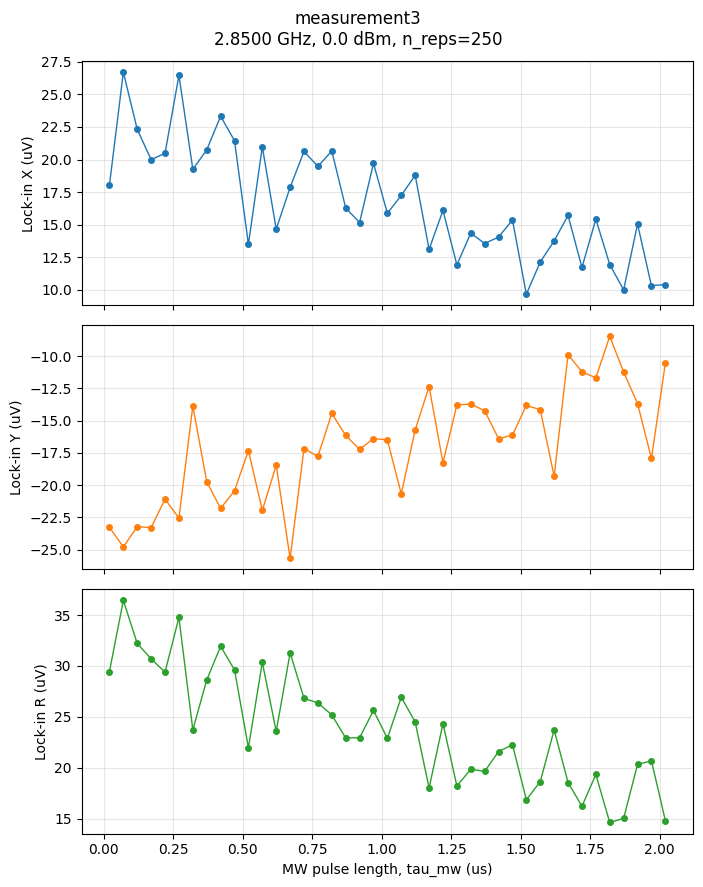

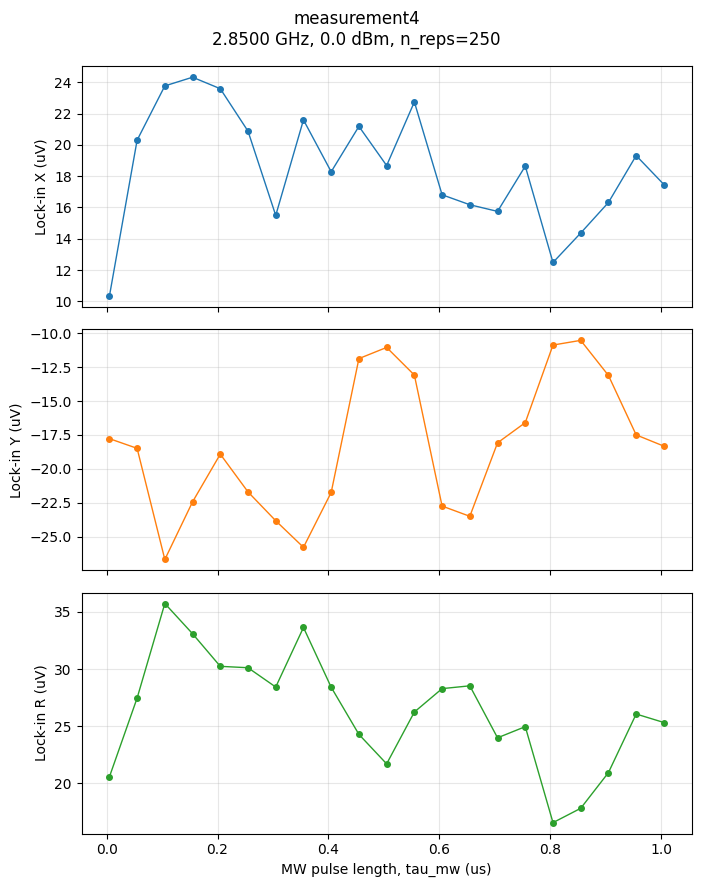

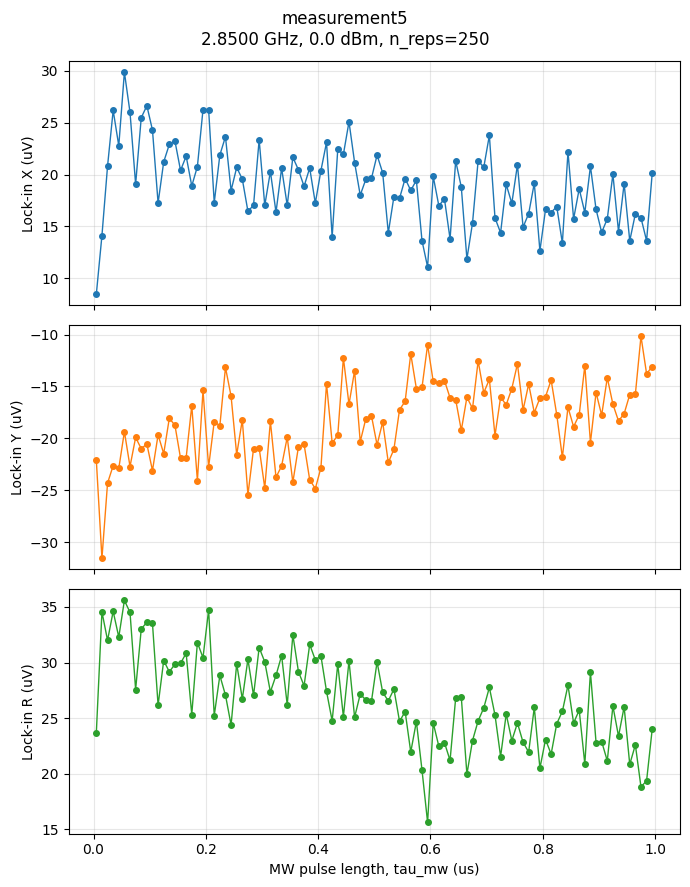

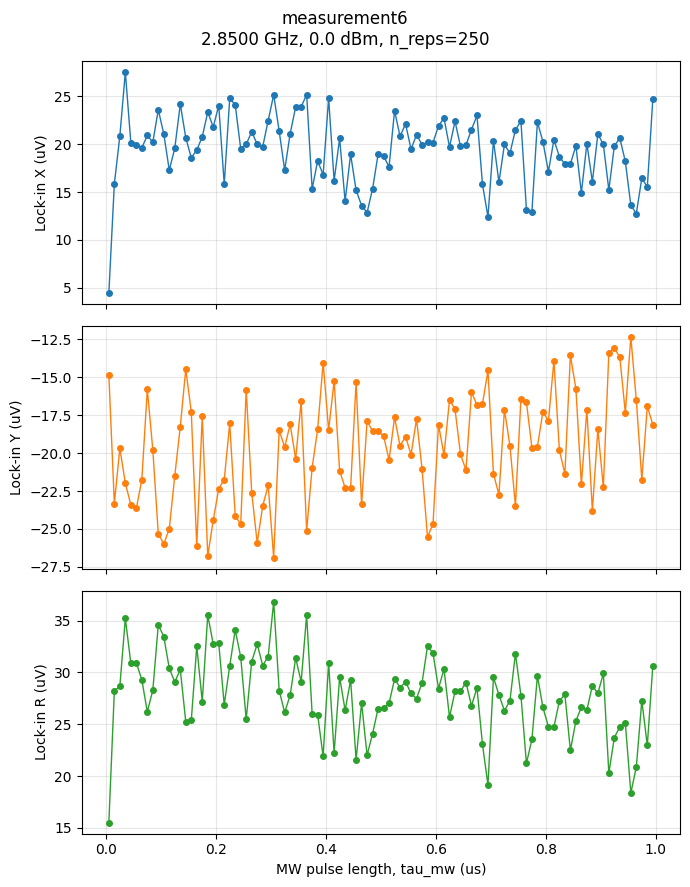

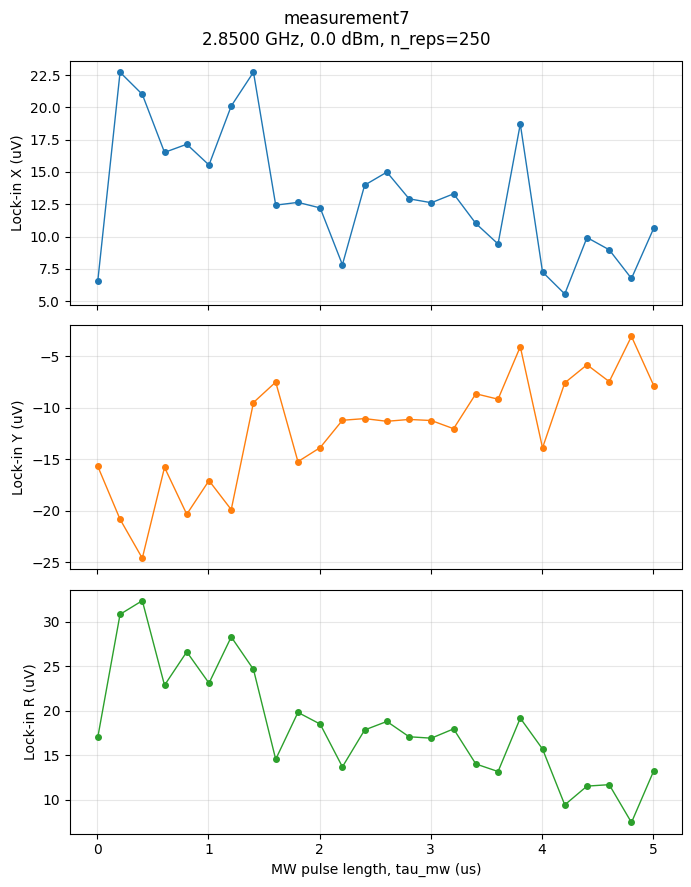

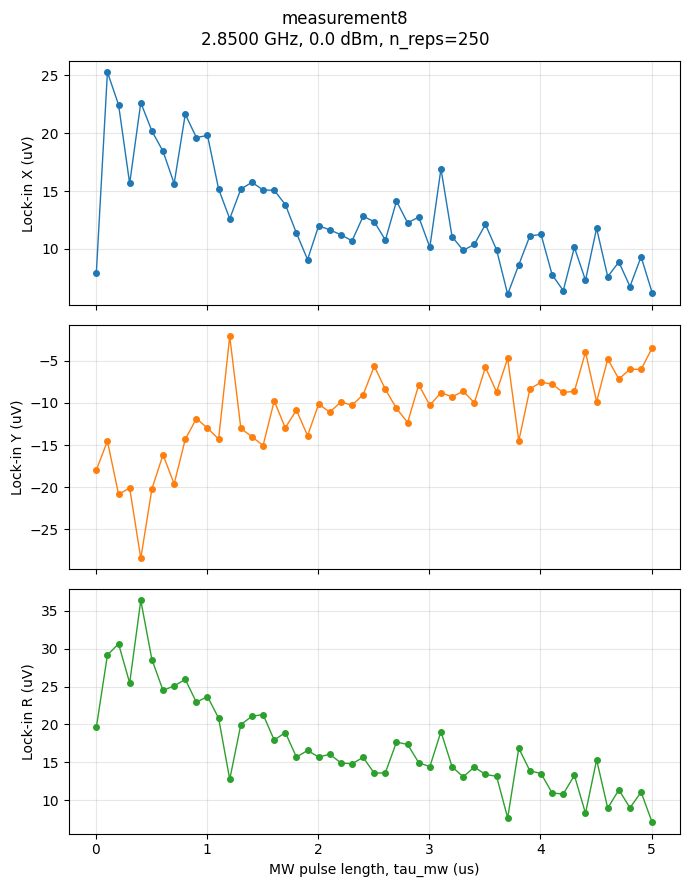

In [2]:
for file_name, d in runs.items():
    r_v = np.sqrt(d["x_v"]**2 + d["y_v"]**2)

    fig, axes = plt.subplots(3, 1, figsize=(7, 9), sharex=True)
    axes[0].plot(d["mw_us"], d["x_v"] * 1e6, "o-", ms=4, lw=1, color="tab:blue")
    axes[1].plot(d["mw_us"], d["y_v"] * 1e6, "o-", ms=4, lw=1, color="tab:orange")
    axes[2].plot(d["mw_us"], r_v * 1e6, "o-", ms=4, lw=1, color="tab:green")

    freq_ghz = d["metadata"]["freq_hz"] / 1e9
    drive_dbm = d["metadata"]["drive_power_dbm"]
    n_reps = int(d["metadata"]["n_reps"])

    axes[0].set_ylabel("Lock-in X (uV)")
    axes[1].set_ylabel("Lock-in Y (uV)")
    axes[2].set_ylabel("Lock-in R (uV)")
    axes[2].set_xlabel("MW pulse length, tau_mw (us)")
    for ax in axes:
        ax.grid(alpha=0.3)

    fig.suptitle(f"{file_name}\n{freq_ghz:.4f} GHz, {drive_dbm:.1f} dBm, n_reps={n_reps}")
    plt.tight_layout()
    plt.show()

## Interlock reflected-power checks

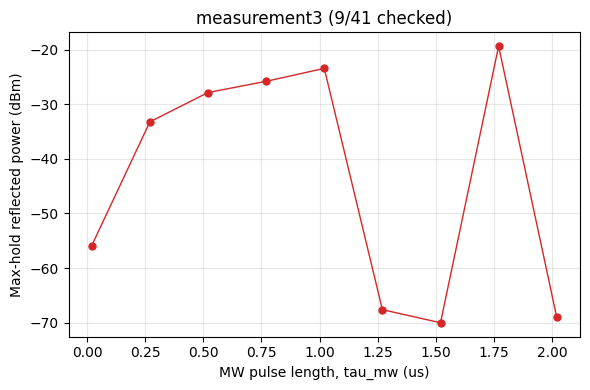

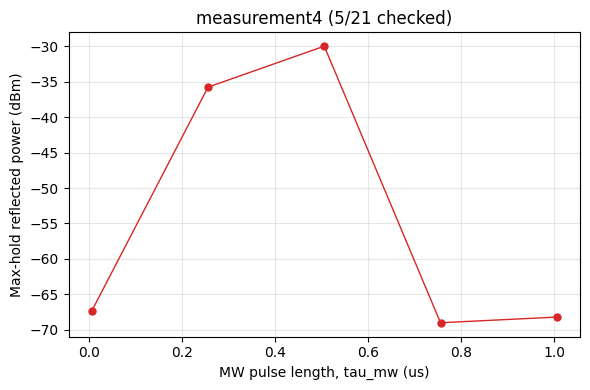

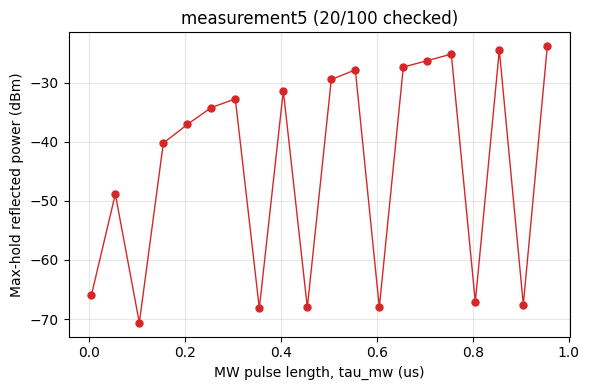

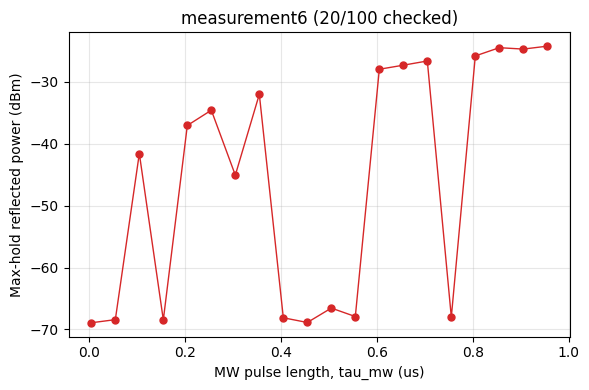

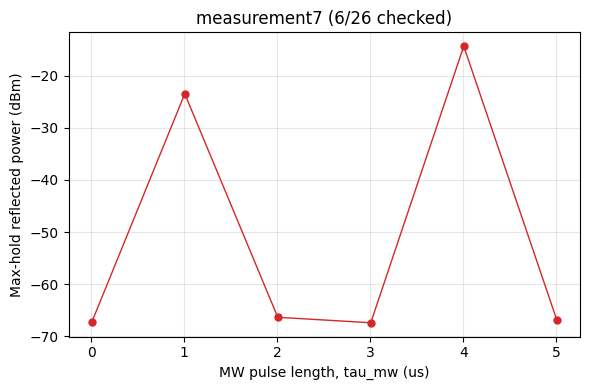

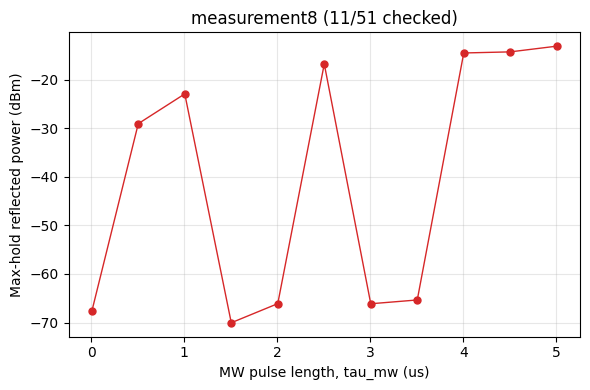

In [3]:
for file_name, d in runs.items():
    checked = ~np.isnan(d["reflected_dbm"])
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.plot(d["mw_us"][checked], d["reflected_dbm"][checked], "o-", ms=5, lw=1, color="tab:red")
    ax.set_xlabel("MW pulse length, tau_mw (us)")
    ax.set_ylabel("Max-hold reflected power (dBm)")
    ax.set_title(f"{file_name} ({checked.sum()}/{len(d['mw_us'])} checked)")
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

## Pre-flight reflected-power sweep

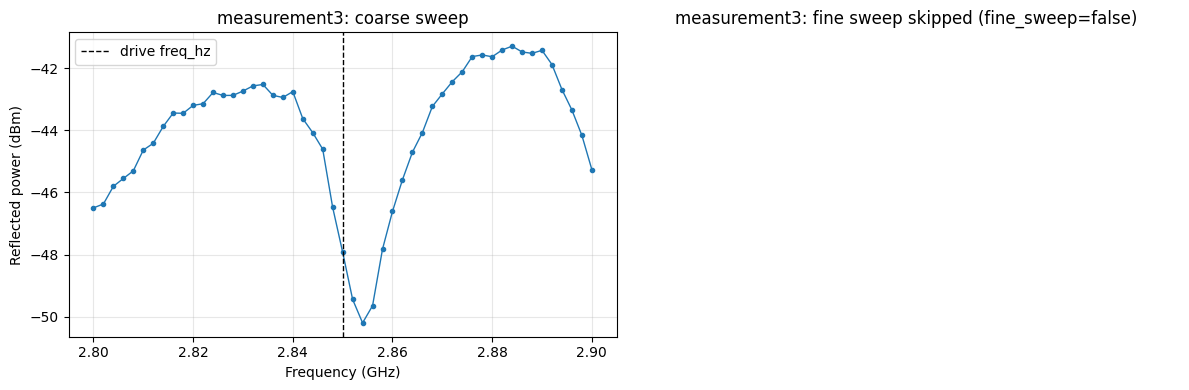

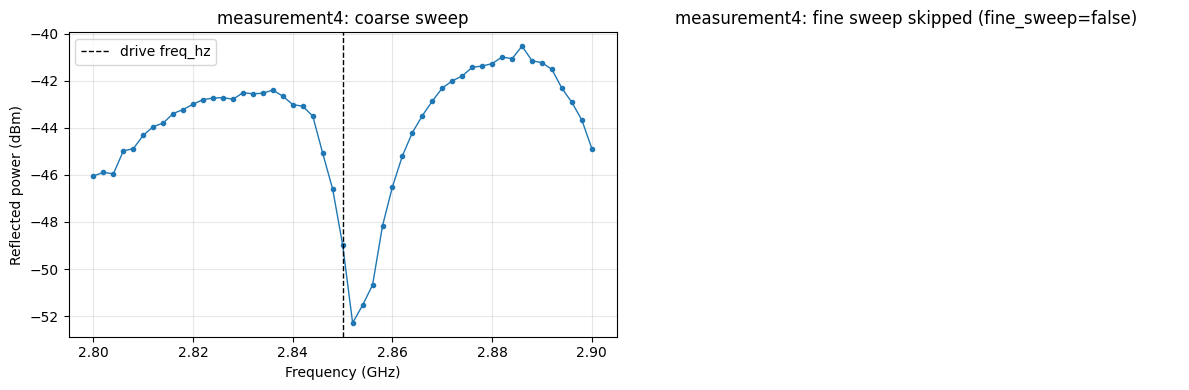

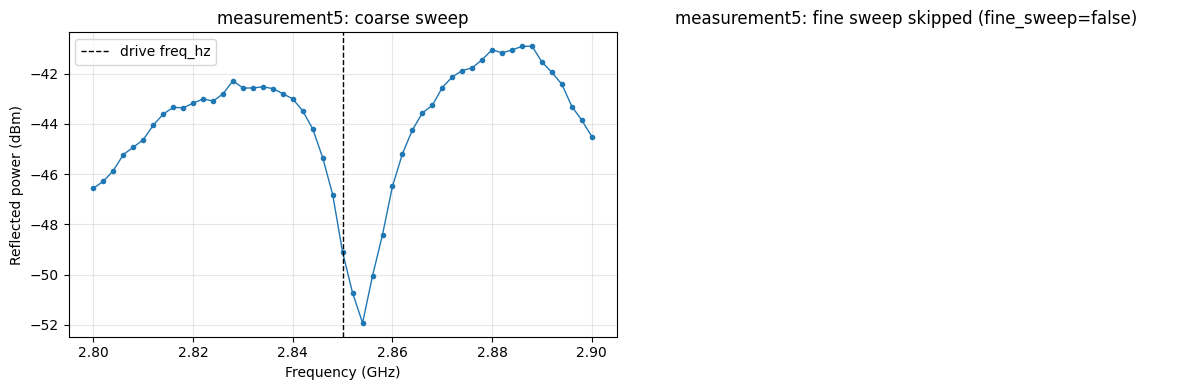

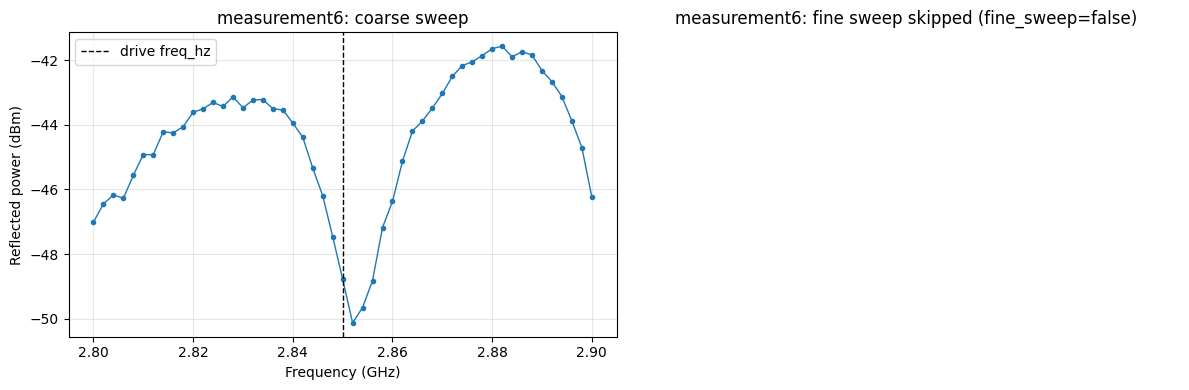

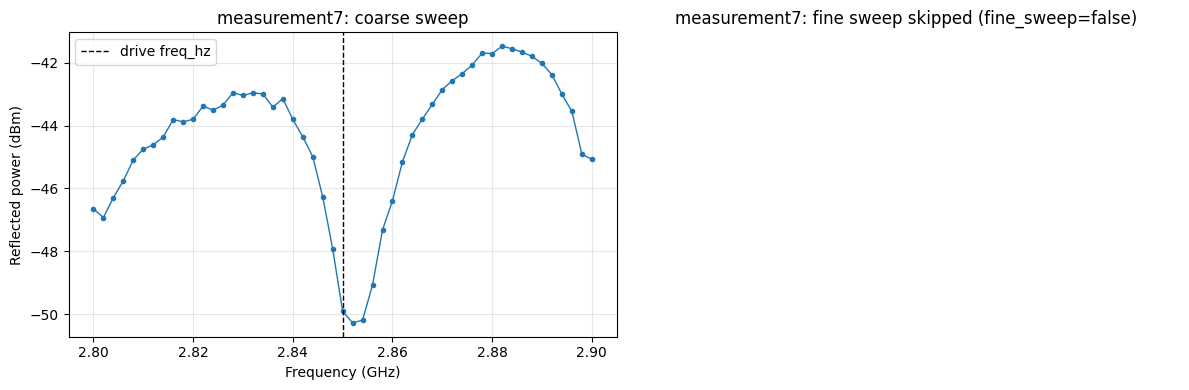

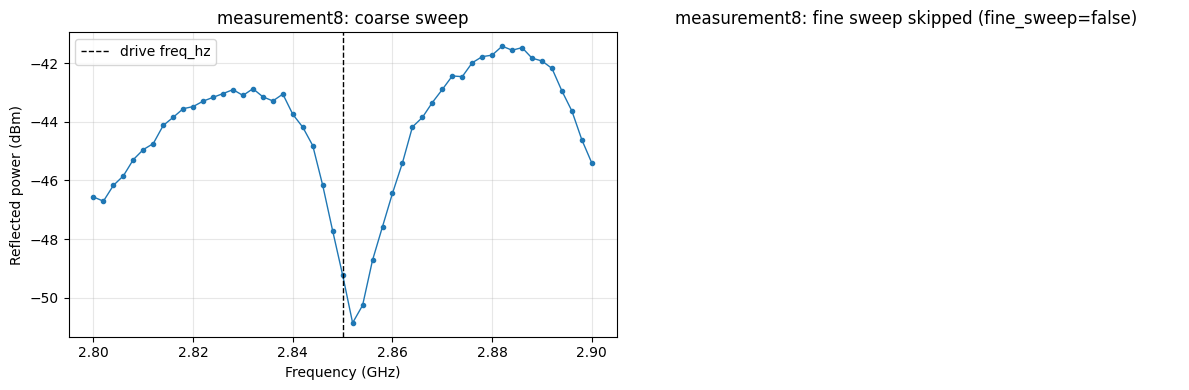

In [4]:
import os

for file_name, d in runs.items():
    coarse_path = f"{d['run_path']}/{file_name}_resonance_coarse.csv"
    fine_path = f"{d['run_path']}/{file_name}_resonance_fine.csv"
    freq_ghz = d["metadata"]["freq_hz"] / 1e9

    if not os.path.exists(coarse_path):
        print(f"{file_name}: no resonance_coarse.csv found "
              "(reflected_power_scan=false, or an older run predating this feature).")
        continue

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    coarse = np.genfromtxt(coarse_path, delimiter=",", names=True)
    axes[0].plot(coarse["frequency_hz"] / 1e9, coarse["power_dbm"], "o-", ms=3, lw=1)
    axes[0].axvline(freq_ghz, color="k", ls="--", lw=1, label="drive freq_hz")
    axes[0].set_xlabel("Frequency (GHz)")
    axes[0].set_ylabel("Reflected power (dBm)")
    axes[0].set_title(f"{file_name}: coarse sweep")
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    if not os.path.exists(fine_path):
        axes[1].set_title(f"{file_name}: fine sweep skipped (fine_sweep=false)")
        axes[1].axis("off")
    else:
        fine = np.genfromtxt(fine_path, delimiter=",", names=True)
        axes[1].plot(fine["frequency_hz"] / 1e9, fine["power_dbm"], "o-", ms=3, lw=1, color="tab:orange")
        axes[1].axvline(freq_ghz, color="k", ls="--", lw=1, label="drive freq_hz")
        axes[1].set_xlabel("Frequency (GHz)")
        axes[1].set_ylabel("Reflected power (dBm)")
        axes[1].set_title(f"{file_name}: fine sweep")
        axes[1].legend()
        axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

## Averaged: measurement5 + measurement6

Elementwise average of X and Y across the two repeats (same `mw_us` grid,
same params), THEN R = sqrt(X^2+Y^2) computed from the averaged X/Y --
never average R directly, since R has a positive noise-rectification bias
that averaging after the fact doesn't remove (see notes.md's
`cw_odmr_lock_in.py` `cmd_sweep_average()` entry for why).

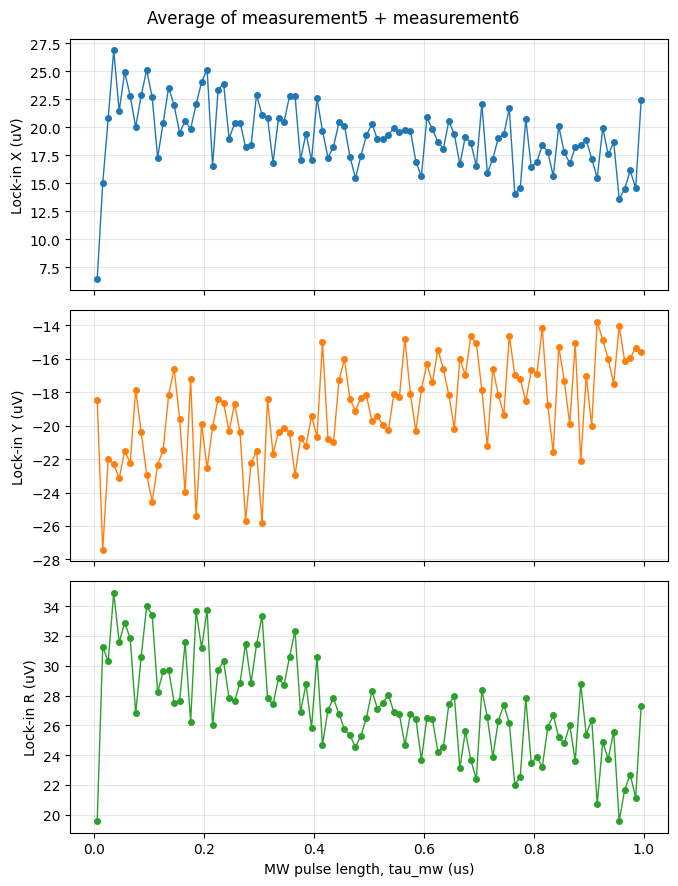

In [5]:
avg_names = ["measurement5", "measurement6"]
d0 = runs[avg_names[0]]
mw_us_avg = d0["mw_us"]
assert all(np.allclose(runs[n]["mw_us"], mw_us_avg) for n in avg_names), \
    "mw_us grids must match exactly to average elementwise"

x_avg = np.mean([runs[n]["x_v"] for n in avg_names], axis=0)
y_avg = np.mean([runs[n]["y_v"] for n in avg_names], axis=0)
r_avg = np.sqrt(x_avg**2 + y_avg**2)

fig, axes = plt.subplots(3, 1, figsize=(7, 9), sharex=True)
axes[0].plot(mw_us_avg, x_avg * 1e6, "o-", ms=4, lw=1, color="tab:blue")
axes[1].plot(mw_us_avg, y_avg * 1e6, "o-", ms=4, lw=1, color="tab:orange")
axes[2].plot(mw_us_avg, r_avg * 1e6, "o-", ms=4, lw=1, color="tab:green")

axes[0].set_ylabel("Lock-in X (uV)")
axes[1].set_ylabel("Lock-in Y (uV)")
axes[2].set_ylabel("Lock-in R (uV)")
axes[2].set_xlabel("MW pulse length, tau_mw (us)")
for ax in axes:
    ax.grid(alpha=0.3)

fig.suptitle(f"Average of {' + '.join(avg_names)}")
plt.tight_layout()
plt.show()

## Averaged: measurement_overnight (all completed repeats so far)

`run-repeat` output -- all repeats and the average share one folder
(`D:/rabi/measurement_overnight/`), distinguished by file name. This is
still running, so this cell auto-discovers however many repeats have
FULLY completed (have a `_rabi_x.npy`) rather than assuming a fixed count,
and only includes repeats whose `mw_us` grid exactly matches the first
one (a repeat that tripped partway through, or is still mid-run, is
excluded rather than skewing the average). Re-run this cell later to pick
up more repeats as they finish.

found 10 completed repeats: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]


averaging 10/10 repeats


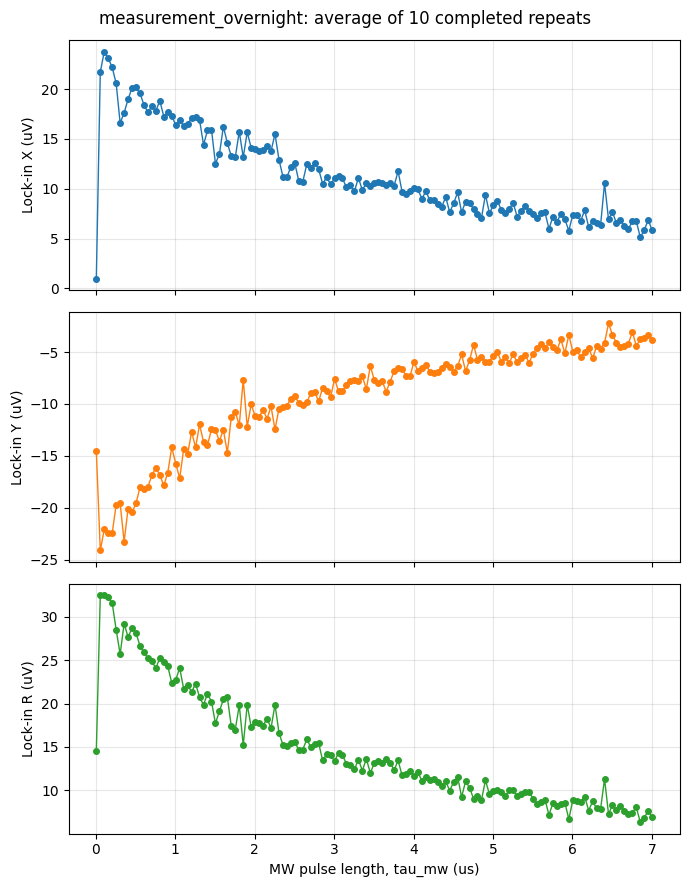

In [6]:
import glob
import re

overnight_name = "measurement_overnight"
overnight_path = f"{DATA_DIR}/{overnight_name}"

repeat_indices = sorted(
    int(re.search(r"_repeat(\d+)_rabi_x\.npy$", p).group(1))
    for p in glob.glob(f"{overnight_path}/{overnight_name}_repeat*_rabi_x.npy")
)
print(f"found {len(repeat_indices)} completed repeats: {repeat_indices}")

mw_us_ref = None
xs, ys = [], []
for i in repeat_indices:
    prefix = f"{overnight_path}/{overnight_name}_repeat{i}"
    mw_us_i = np.load(f"{prefix}_rabi_mw_us.npy")
    if mw_us_ref is None:
        mw_us_ref = mw_us_i
    elif len(mw_us_i) != len(mw_us_ref) or not np.allclose(mw_us_i, mw_us_ref):
        print(f"  repeat{i}: mw_us grid mismatch ({len(mw_us_i)} vs {len(mw_us_ref)} points) -- excluded")
        continue
    xs.append(np.load(f"{prefix}_rabi_x.npy"))
    ys.append(np.load(f"{prefix}_rabi_y.npy"))

print(f"averaging {len(xs)}/{len(repeat_indices)} repeats")

x_avg = np.mean(xs, axis=0)
y_avg = np.mean(ys, axis=0)
r_avg = np.sqrt(x_avg**2 + y_avg**2)

fig, axes = plt.subplots(3, 1, figsize=(7, 9), sharex=True)
axes[0].plot(mw_us_ref, x_avg * 1e6, "o-", ms=4, lw=1, color="tab:blue")
axes[1].plot(mw_us_ref, y_avg * 1e6, "o-", ms=4, lw=1, color="tab:orange")
axes[2].plot(mw_us_ref, r_avg * 1e6, "o-", ms=4, lw=1, color="tab:green")

axes[0].set_ylabel("Lock-in X (uV)")
axes[1].set_ylabel("Lock-in Y (uV)")
axes[2].set_ylabel("Lock-in R (uV)")
axes[2].set_xlabel("MW pulse length, tau_mw (us)")
for ax in axes:
    ax.grid(alpha=0.3)

fig.suptitle(f"{overnight_name}: average of {len(xs)} completed repeats")
plt.tight_layout()
plt.show()